# The Forgetting Curve: Predicting Memory Recall (No Data Leakage)

## Project Overview

This notebook predicts `p_recall` (probability of word recall) using only context variables available before a session starts. We exclude `session_correct` and `session_seen` because they are the formula components of the target (`p_recall = session_correct / session_seen`). Including them would be data leakage.

We use the full dataset (all 499K sessions, including perfect recall cases) because a real spaced repetition system needs to predict both: which words will be remembered perfectly and which will be forgotten.

**Use case**: Duolingo needs to decide which words to show a learner today. The model predicts recall probability from context (time elapsed, practice history, word difficulty, language) to prioritise words likely to be forgotten.

## Pipeline
1. Data Loading and Exploratory Analysis
2. Feature Engineering (excluding session variables)
3. Feature Scaling
4. Feature Selection
5. Supervised Learning: Linear Regression, Random Forest, Neural Network
6. Hyperparameter Tuning
7. Model Evaluation and Comparison
8. NLP Features: Do They Help?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# Load all datasets
df = pd.read_csv('data/learning_traces_sample.csv')
df_curve = pd.read_csv('data/forgetting_curve.csv')
df_words = pd.read_csv('data/word_difficulty.csv')
df_courses = pd.read_csv('data/language_courses.csv')

print(f"Main dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Forgetting curve: {df_curve.shape}")
print(f"Word difficulty: {df_words.shape}")
print(f"Language courses: {df_courses.shape}")

Main dataset: 499,436 rows x 15 columns
Forgetting curve: (310, 10)
Word difficulty: (6211, 12)
Language courses: (8, 11)


In [3]:
df.head()

,practice_time,user_id,ui_language,learning_language,surface_form,lemma,pos,grammar_tags,lag_days,history_seen,history_correct,session_seen,session_correct,p_recall,lexeme_id
0,2013-02-28 20:11:37,u:FO,en,de,lernt,lernen,vblex,pri;p3;sg,0.003,14,12,1,0,0.000000,76390c1350a8dac31186187e2fe1e178
1,2013-02-28 20:14:53,u:g3WM,en,pt,leão,leão,n,m;sg,0.017,9,8,1,1,1.000000,4b3613233b3fede2e3e92ac2ef752bf6
2,2013-02-28 20:14:53,u:g3WM,en,pt,roupa,roupa,n,f;*numb,13.791,1,1,1,1,1.000000,3a898602c268f23d8acbeadacc9138be
3,2013-02-28 20:15:21,u:hl1O,en,de,nudeln,nudel,n,f;pl;*case,20.451,2,2,3,2,0.666667,3fb0c6ae83598ec3e6817e2e236e3b9b
4,2013-02-28 20:15:27,u:h5ex,en,de,zucker,zucker,n,m;sg;dat,0.002,2,1,1,1,1.000000,a8f2e402075e0670edf17d20c1329fa9


In [4]:
df.info()
print("\n")
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 499436 entries, 0 to 499435
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   practice_time      499436 non-null  str    
 1   user_id            499436 non-null  str    
 2   ui_language        499436 non-null  str    
 3   learning_language  499436 non-null  str    
 4   surface_form       499436 non-null  str    
 5   lemma              499436 non-null  str    
 6   pos                499436 non-null  str    
 7   grammar_tags       448480 non-null  str    
 8   lag_days           499436 non-null  float64
 9   history_seen       499436 non-null  int64  
 10  history_correct    499436 non-null  int64  
 11  session_seen       499436 non-null  int64  
 12  session_correct    499436 non-null  int64  
 13  p_recall           499436 non-null  float64
 14  lexeme_id          499436 non-null  str    
dtypes: float64(2), int64(4), str(9)
memory usage: 57.2 MB




,lag_days,history_seen,history_correct,session_seen,session_correct,p_recall
count,499436.000000,499436.000000,499436.000000,499436.000000,499436.000000,499436.000000
mean,8.426820,21.795071,19.229473,1.819643,1.645929,0.896076
std,25.921927,132.212007,115.861608,1.362531,1.321230,0.271270
min,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,0.006000,3.000000,3.000000,1.000000,1.000000,1.000000
50%,0.895000,6.000000,6.000000,1.000000,1.000000,1.000000
75%,5.128000,15.000000,13.000000,2.000000,2.000000,1.000000
max,466.389000,13447.000000,12821.000000,20.000000,20.000000,1.000000


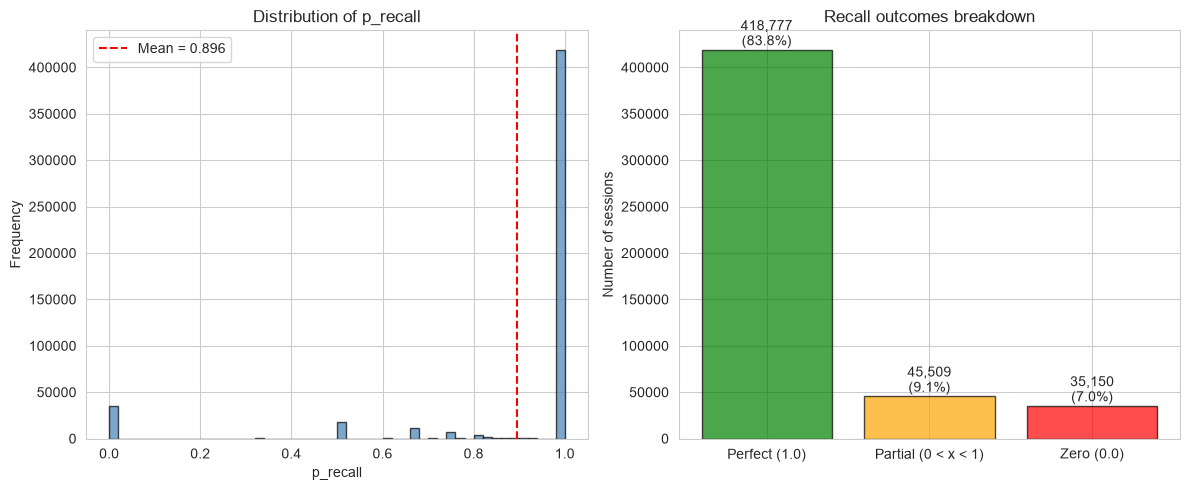

In [5]:
# Distribution of p_recall
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df['p_recall'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('p_recall')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of p_recall')
axes[0].axvline(df['p_recall'].mean(), color='red', linestyle='--', label=f"Mean = {df['p_recall'].mean():.3f}")
axes[0].legend()

perfect = (df['p_recall'] == 1.0).sum()
partial = ((df['p_recall'] > 0) & (df['p_recall'] < 1)).sum()
zero = (df['p_recall'] == 0).sum()

labels = ['Perfect (1.0)', 'Partial (0 < x < 1)', 'Zero (0.0)']
sizes = [perfect, partial, zero]
axes[1].bar(labels, sizes, color=['green', 'orange', 'red'], alpha=0.7, edgecolor='black')
axes[1].set_ylabel('Number of sessions')
axes[1].set_title('Recall outcomes breakdown')
for i, v in enumerate(sizes):
    axes[1].text(i, v + 5000, f"{v:,}\n({v/len(df)*100:.1f}%)", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

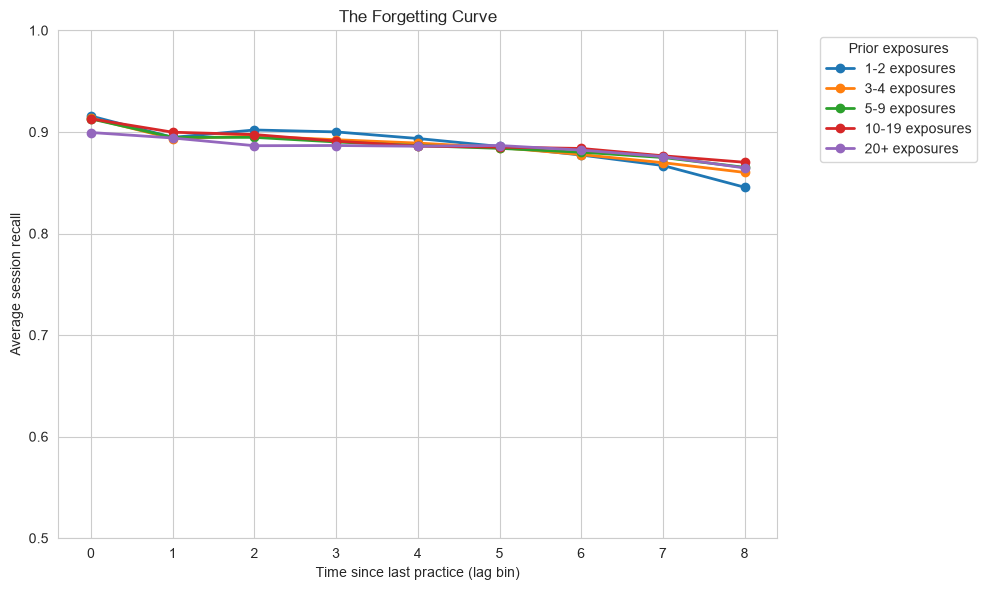

In [6]:
# The forgetting curve: recall vs time, grouped by prior exposure level
curve_all = df_curve[df_curve['learning_language'] == 'all'].copy()

fig, ax = plt.subplots(figsize=(10, 6))
for practice_bin in curve_all['practice_bin'].unique():
    subset = curve_all[curve_all['practice_bin'] == practice_bin]
    ax.plot(subset['lag_bin_order'], subset['avg_session_recall'], 
            marker='o', linewidth=2, label=practice_bin)

ax.set_xlabel('Time since last practice (lag bin)')
ax.set_ylabel('Average session recall')
ax.set_title('The Forgetting Curve')
ax.legend(title='Prior exposures', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_ylim(0.5, 1.0)
plt.tight_layout()
plt.show()

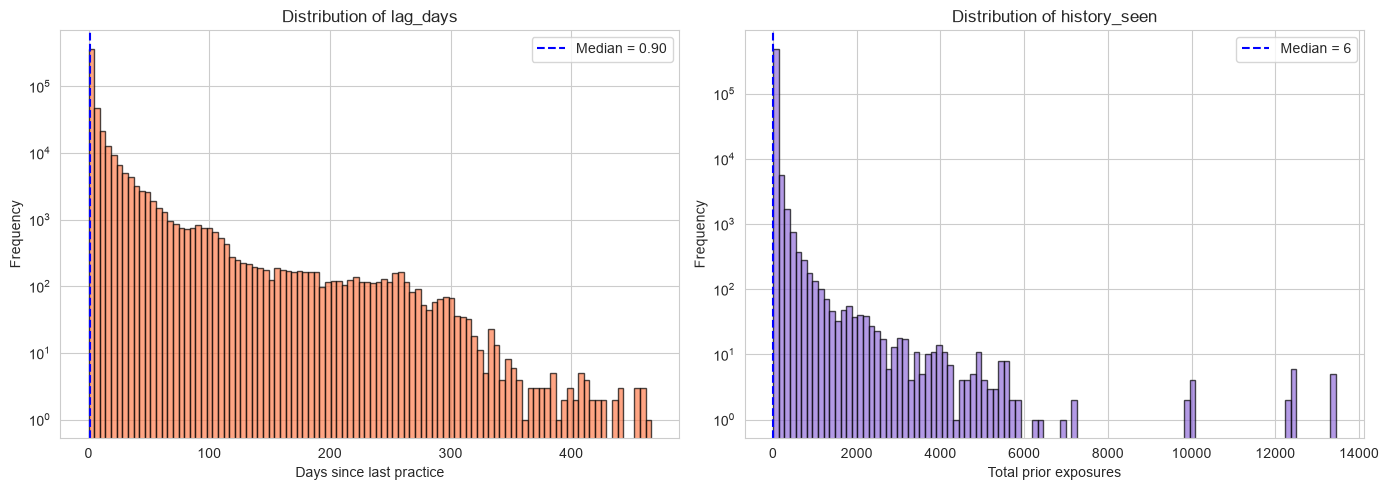

In [7]:
# Distributions of lag_days and history_seen (both heavily right-skewed)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['lag_days'], bins=100, edgecolor='black', alpha=0.7, color='coral')
axes[0].set_xlabel('Days since last practice')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of lag_days')
axes[0].set_yscale('log')
axes[0].axvline(df['lag_days'].median(), color='blue', linestyle='--', 
                label=f"Median = {df['lag_days'].median():.2f}")
axes[0].legend()

axes[1].hist(df['history_seen'], bins=100, edgecolor='black', alpha=0.7, color='mediumpurple')
axes[1].set_xlabel('Total prior exposures')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of history_seen')
axes[1].set_yscale('log')
axes[1].axvline(df['history_seen'].median(), color='blue', linestyle='--',
                label=f"Median = {df['history_seen'].median():.0f}")
axes[1].legend()

plt.tight_layout()
plt.show()

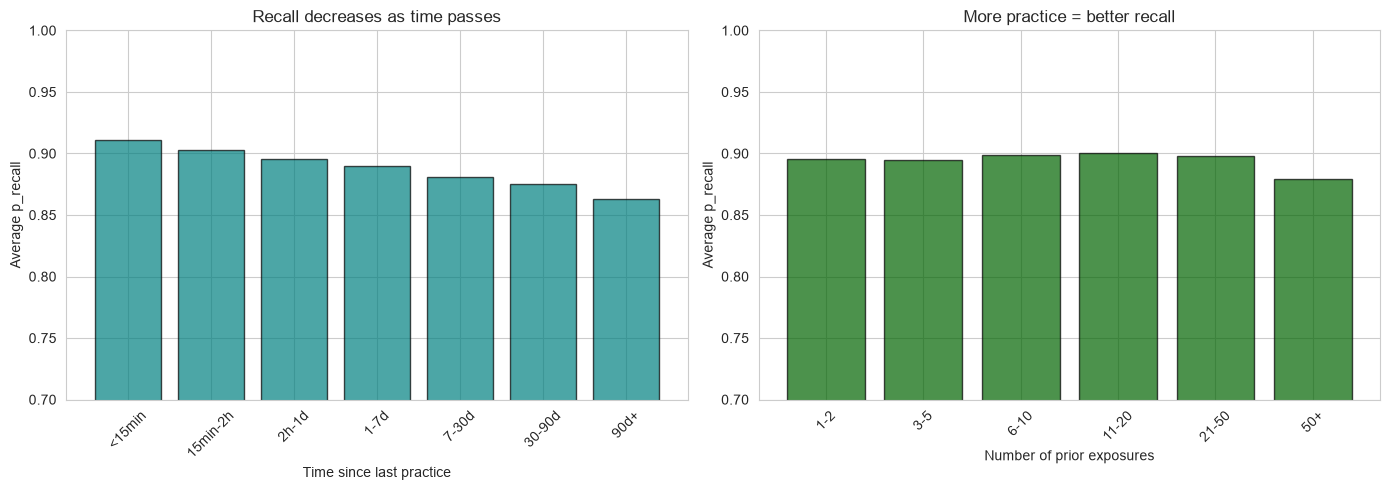

In [8]:
# Average recall by time lag and by number of prior exposures
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['lag_bin_custom'] = pd.cut(df['lag_days'], bins=[0, 0.01, 0.1, 1, 7, 30, 90, 500], 
                               labels=['<15min', '15min-2h', '2h-1d', '1-7d', '7-30d', '30-90d', '90d+'])
recall_by_lag = df.groupby('lag_bin_custom', observed=True)['p_recall'].mean()
axes[0].bar(range(len(recall_by_lag)), recall_by_lag.values, color='teal', alpha=0.7, edgecolor='black')
axes[0].set_xticks(range(len(recall_by_lag)))
axes[0].set_xticklabels(recall_by_lag.index, rotation=45)
axes[0].set_xlabel('Time since last practice')
axes[0].set_ylabel('Average p_recall')
axes[0].set_title('Recall decreases as time passes')
axes[0].set_ylim(0.7, 1.0)

df['exposure_bin'] = pd.cut(df['history_seen'], bins=[0, 2, 5, 10, 20, 50, 15000],
                            labels=['1-2', '3-5', '6-10', '11-20', '21-50', '50+'])
recall_by_exposure = df.groupby('exposure_bin', observed=True)['p_recall'].mean()
axes[1].bar(range(len(recall_by_exposure)), recall_by_exposure.values, color='darkgreen', alpha=0.7, edgecolor='black')
axes[1].set_xticks(range(len(recall_by_exposure)))
axes[1].set_xticklabels(recall_by_exposure.index, rotation=45)
axes[1].set_xlabel('Number of prior exposures')
axes[1].set_ylabel('Average p_recall')
axes[1].set_title('More practice = better recall')
axes[1].set_ylim(0.7, 1.0)

plt.tight_layout()
plt.show()

df.drop(columns=['lag_bin_custom', 'exposure_bin'], inplace=True)

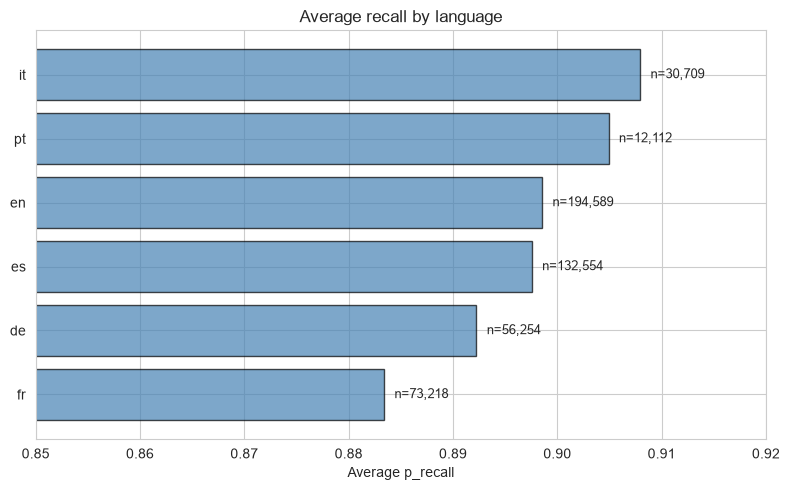

In [9]:
# Recall by language
fig, ax = plt.subplots(figsize=(8, 5))
recall_by_lang = df.groupby('learning_language')['p_recall'].agg(['mean', 'count']).sort_values('mean')
ax.barh(recall_by_lang.index, recall_by_lang['mean'], color='steelblue', alpha=0.7, edgecolor='black')
ax.set_xlabel('Average p_recall')
ax.set_title('Average recall by language')
ax.set_xlim(0.85, 0.92)
for i, (lang, row) in enumerate(recall_by_lang.iterrows()):
    ax.text(row['mean'] + 0.001, i, f"n={row['count']:,.0f}", va='center', fontsize=9)
plt.tight_layout()
plt.show()

### EDA Summary

- 499,436 learning events, 75,294 users, 6 languages
- `p_recall` is concentrated at 1.0 (84% perfect recall). Only 7% total failure.
- Forgetting effect confirmed: recall drops from 91% at short lags to 86% at 90+ days
- `lag_days` and `history_seen` are extremely right-skewed (skew 6.6 and 44 respectively), with heavy outliers. This justifies using RobustScaler later.
- Only `grammar_tags` has missing values (10.2%), expected for words without annotations
- French and German show lowest recall; Italian and Portuguese the highest

## 2. Feature Engineering

In [10]:
# Derived features
df['history_correct_rate'] = df['history_correct'] / df['history_seen']
df['log_lag_days'] = np.log1p(df['lag_days'])  # log(1+x) to handle lag_days=0

# Merge word difficulty info
df = df.merge(df_words[['lexeme_id', 'difficulty_rank_in_language']], on='lexeme_id', how='left')

# Encode learning_language (only 6 values, one-hot is fine)
lang_dummies = pd.get_dummies(df['learning_language'], prefix='lang')
df = pd.concat([df, lang_dummies], axis=1)

# Part of speech: too many (73), group into top categories + "other"
top_pos = df['pos'].value_counts().head(10).index
df['pos_grouped'] = df['pos'].where(df['pos'].isin(top_pos), other='other')
pos_dummies = pd.get_dummies(df['pos_grouped'], prefix='pos')
df = pd.concat([df, pos_dummies], axis=1)

print(f"Shape after feature engineering: {df.shape}")

Shape after feature engineering: (499436, 36)


In [11]:
# Drop columns we won't use for modelling
# session_correct and session_seen are excluded (data leakage: p_recall = session_correct/session_seen)
cols_to_drop = ['practice_time', 'user_id', 'ui_language', 'learning_language',
                'surface_form', 'lemma', 'pos', 'grammar_tags', 'lexeme_id', 'pos_grouped',
                'session_correct', 'session_seen']
df_model = df.drop(columns=cols_to_drop)

print(f"Final modelling DataFrame: {df_model.shape}")
print(f"\nColumns:\n{list(df_model.columns)}")
print(f"\nNull count: {df_model.isnull().sum().sum()}")

Final modelling DataFrame: (499436, 24)

Columns:
['lag_days', 'history_seen', 'history_correct', 'p_recall', 'history_correct_rate', 'log_lag_days', 'difficulty_rank_in_language', 'lang_de', 'lang_en', 'lang_es', 'lang_fr', 'lang_it', 'lang_pt', 'pos_adj', 'pos_adv', 'pos_cnjcoo', 'pos_det', 'pos_ij', 'pos_n', 'pos_other', 'pos_pr', 'pos_prn', 'pos_vblex', 'pos_vbser']

Null count: 9863


In [12]:
# Fill missing difficulty ranks with median (words not in the difficulty file)
median_diff = df_model['difficulty_rank_in_language'].median()
df_model['difficulty_rank_in_language'] = df_model['difficulty_rank_in_language'].fillna(median_diff)
print(f"Nulls remaining: {df_model.isnull().sum().sum()}")

Nulls remaining: 0


## 3. Feature Scaling

We use RobustScaler for the continuous numeric features because `lag_days` and `history_seen` have extreme outliers (skewness > 6). RobustScaler uses median and IQR instead of mean and standard deviation, so outliers do not distort the scaling. Binary columns (one-hot encoded) are already 0/1 and do not need scaling.

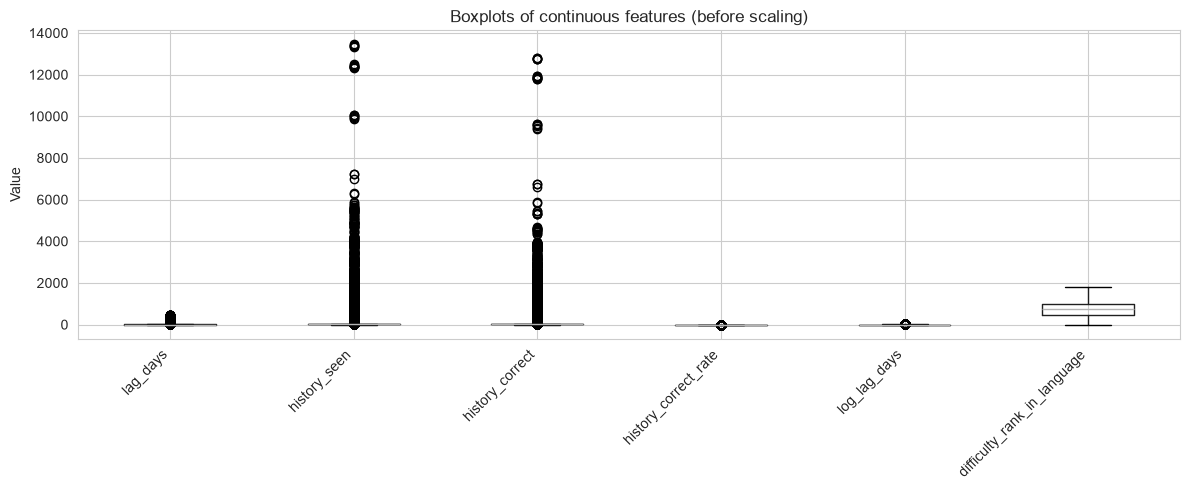

In [13]:
# Boxplots to visualise outliers in continuous features before scaling
continuous_cols = ['lag_days', 'history_seen', 'history_correct',
                  'history_correct_rate', 'log_lag_days', 'difficulty_rank_in_language']

fig, ax = plt.subplots(figsize=(12, 5))
df_model[continuous_cols].boxplot(ax=ax, vert=True)
ax.set_title('Boxplots of continuous features (before scaling)')
ax.set_ylabel('Value')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [14]:
from sklearn.preprocessing import RobustScaler

# Separate features and target
X = df_model.drop(columns=['p_recall'])
y = df_model['p_recall']

# Scale only the continuous columns, leave binary (one-hot) columns as is
binary_cols = [c for c in X.columns if X[c].isin([0, 1, True, False]).all()]
continuous_cols = [c for c in X.columns if c not in binary_cols]

scaler = RobustScaler()
X[continuous_cols] = scaler.fit_transform(X[continuous_cols])

print(f"Scaled {len(continuous_cols)} continuous features: {continuous_cols}")
print(f"Left {len(binary_cols)} binary features unchanged")
print(f"\nX shape: {X.shape}, y shape: {y.shape}")

Scaled 6 continuous features: ['lag_days', 'history_seen', 'history_correct', 'history_correct_rate', 'log_lag_days', 'difficulty_rank_in_language']
Left 17 binary features unchanged

X shape: (499436, 23), y shape: (499436,)


## 4. Feature Selection

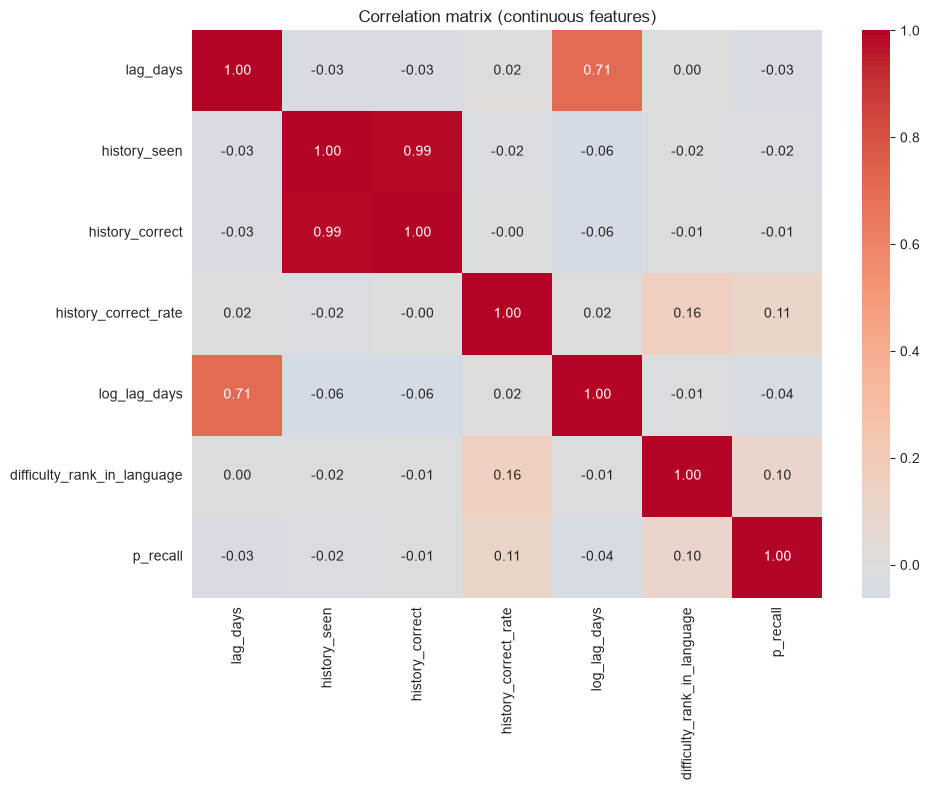

In [15]:
# Correlation matrix (Pearson) to detect redundancy between features
# and see which features correlate most with the target
df_corr = X.copy()
df_corr['p_recall'] = y

corr_matrix = df_corr.corr()

# Plot heatmap (continuous features only, for readability)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix.loc[continuous_cols + ['p_recall'], continuous_cols + ['p_recall']], 
            annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation matrix (continuous features)')
plt.tight_layout()
plt.show()

In [16]:
# Correlation of each feature with the target
print("Correlation with p_recall (sorted by absolute value):\n")
corr_with_target = corr_matrix['p_recall'].drop('p_recall').abs().sort_values(ascending=False)
print(corr_with_target.round(3).to_string())

Correlation with p_recall (sorted by absolute value):

history_correct_rate           0.105
difficulty_rank_in_language    0.101
log_lag_days                   0.044
lag_days                       0.029
pos_n                          0.023
pos_ij                         0.022
pos_pr                         0.022
history_seen                   0.020
lang_fr                        0.019
pos_det                        0.016
pos_cnjcoo                     0.011
lang_it                        0.011
history_correct                0.011
pos_other                      0.008
lang_en                        0.007
pos_adj                        0.006
pos_prn                        0.005
lang_pt                        0.005
lang_de                        0.005
pos_adv                        0.005
pos_vblex                      0.003
lang_es                        0.003
pos_vbser                      0.001


In [17]:
# Lasso regression (L1) to automatically select features
# L1 penalty forces unimportant feature coefficients to exactly zero
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.001, max_iter=10000)
lasso.fit(X, y)

# Show which features survived (non-zero coefficients)
lasso_coefs = pd.Series(lasso.coef_, index=X.columns).sort_values(key=abs, ascending=False)
print("Lasso coefficients (alpha=0.001):\n")
print(lasso_coefs.round(4).to_string())
print(f"\nFeatures eliminated (coef = 0): {(lasso_coefs == 0).sum()}")

Lasso coefficients (alpha=0.001):

difficulty_rank_in_language    0.0396
history_correct_rate           0.0271
lang_en                       -0.0211
log_lag_days                  -0.0149
lang_it                        0.0109
history_seen                  -0.0063
history_correct                0.0057
lang_es                       -0.0054
lag_days                      -0.0002
pos_ij                         0.0000
pos_vblex                     -0.0000
pos_prn                        0.0000
pos_pr                        -0.0000
pos_other                     -0.0000
pos_n                          0.0000
lang_pt                        0.0000
pos_det                       -0.0000
pos_cnjcoo                    -0.0000
pos_adv                       -0.0000
pos_adj                        0.0000
lang_fr                        0.0000
lang_de                       -0.0000
pos_vbser                      0.0000

Features eliminated (coef = 0): 14


### Feature Selection Summary

From the correlation matrix:
- `history_seen` and `history_correct` are 0.99 correlated (redundant). We drop `history_correct`.
- `lag_days` and `log_lag_days` are 0.71 correlated. We keep `log_lag_days` (better for models due to compressed scale) and drop `lag_days`.

From Lasso (L1):
- Only a few features have non-zero coefficients: `difficulty_rank_in_language`, `history_correct_rate`, `log_lag_days`, `history_seen`.
- Language and POS dummies are eliminated. However, we keep them for the models since tree-based methods (Random Forest) may still use them through non-linear splits.

We drop only the clearly redundant features: `history_correct` and `lag_days`.

In [18]:
# Drop redundant features
X = X.drop(columns=['history_correct', 'lag_days'])
print(f"Final feature set: {X.shape[1]} features, {X.shape[0]:,} samples")

Final feature set: 21 features, 499,436 samples


## 5. Supervised Learning: Predicting Recall

We train three models of increasing complexity to predict `p_recall` and compare their performance using RMSE and R².

In [19]:
# Train/test split (80/20)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape[0]:,} samples")
print(f"Test:  {X_test.shape[0]:,} samples")

Train: 399,548 samples
Test:  99,888 samples


In [20]:
# Model 1: Linear Regression (baseline)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)
print(f"Linear Regression:  RMSE = {rmse_lr:.4f}, R² = {r2_lr:.4f}")

Linear Regression:  RMSE = 0.2679, R² = 0.0244


In [21]:
# Model 2: Random Forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
print(f"Random Forest:      RMSE = {rmse_rf:.4f}, R² = {r2_rf:.4f}")

Random Forest:      RMSE = 0.2677, R² = 0.0264


In [22]:
# Model 3: Neural Network (MLP) with Keras
import tensorflow as tf
from tensorflow import keras

model = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')  # output between 0 and 1, like p_recall
])

model.compile(optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9), loss='mse', metrics=['mae'])
history = model.fit(X_train, y_train, epochs=20, batch_size=256, 
                    validation_split=0.1, verbose=0)

y_pred_nn = model.predict(X_test, verbose=0).flatten()
rmse_nn = np.sqrt(mean_squared_error(y_test, y_pred_nn))
r2_nn = r2_score(y_test, y_pred_nn)
print(f"Neural Network:     RMSE = {rmse_nn:.4f}, R² = {r2_nn:.4f}")

/Users/I767808/Documents/data-science-i/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Neural Network:     RMSE = 0.2670, R² = 0.0309


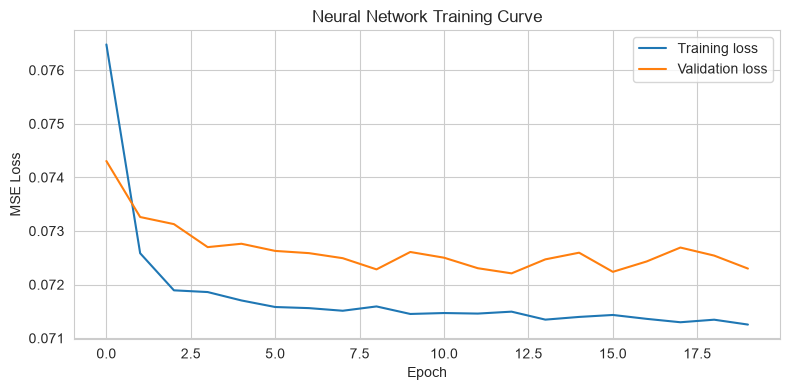

In [23]:
# Training loss curve for the neural network
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history.history['loss'], label='Training loss')
ax.plot(history.history['val_loss'], label='Validation loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Neural Network Training Curve')
ax.legend()
plt.tight_layout()
plt.show()

In [24]:
# Model comparison summary
print("=" * 50)
print("MODEL COMPARISON")
print("=" * 50)
print(f"{'Model':<20} {'RMSE':<10} {'R²':<10}")
print("-" * 50)
print(f"{'Linear Regression':<20} {rmse_lr:<10.4f} {r2_lr:<10.4f}")
print(f"{'Random Forest':<20} {rmse_rf:<10.4f} {r2_rf:<10.4f}")
print(f"{'Neural Network':<20} {rmse_nn:<10.4f} {r2_nn:<10.4f}")
print("-" * 50)

MODEL COMPARISON
Model                RMSE       R²        
--------------------------------------------------
Linear Regression    0.2679     0.0244    
Random Forest        0.2677     0.0264    
Neural Network       0.2670     0.0309    
--------------------------------------------------


## 6. Hyperparameter Tuning

We use RandomizedSearchCV to check whether tuning hyperparameters can improve the Random Forest beyond R² = 0.026.

In [25]:
# RandomizedSearchCV on Random Forest
# Using a sample for speed (tuning on full dataset is computationally expensive)
from sklearn.model_selection import RandomizedSearchCV

X_sample, _, y_sample, _ = train_test_split(X_train, y_train, train_size=50000, random_state=42)

param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=10, cv=3, scoring='r2', random_state=42, verbose=0
)
rf_search.fit(X_sample, y_sample)

print(f"Best params: {rf_search.best_params_}")
print(f"Best CV R²:  {rf_search.best_score_:.4f}")

# Evaluate best model on full test set
y_pred_tuned = rf_search.best_estimator_.predict(X_test)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_tuned = r2_score(y_test, y_pred_tuned)
print(f"\nTuned RF on test set: RMSE = {rmse_tuned:.4f}, R² = {r2_tuned:.4f}")
print(f"Original RF:          RMSE = {rmse_rf:.4f}, R² = {r2_rf:.4f}")

Best params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 10}
Best CV R²:  0.0230

Tuned RF on test set: RMSE = 0.2677, R² = 0.0263
Original RF:          RMSE = 0.2677, R² = 0.0264


## 7. Model Evaluation and Comparison

In [26]:
# Final comparison table
print("=" * 55)
print("FINAL MODEL COMPARISON (test set)")
print("=" * 55)
print(f"{'Model':<25} {'RMSE':<10} {'R²':<10}")
print("-" * 55)
print(f"{'Linear Regression':<25} {rmse_lr:<10.4f} {r2_lr:<10.4f}")
print(f"{'Random Forest':<25} {rmse_rf:<10.4f} {r2_rf:<10.4f}")
print(f"{'Random Forest (tuned)':<25} {rmse_tuned:<10.4f} {r2_tuned:<10.4f}")
print(f"{'Neural Network':<25} {rmse_nn:<10.4f} {r2_nn:<10.4f}")
print("=" * 55)

FINAL MODEL COMPARISON (test set)
Model                     RMSE       R²        
-------------------------------------------------------
Linear Regression         0.2679     0.0244    
Random Forest             0.2677     0.0264    
Random Forest (tuned)     0.2677     0.0263    
Neural Network            0.2670     0.0309    


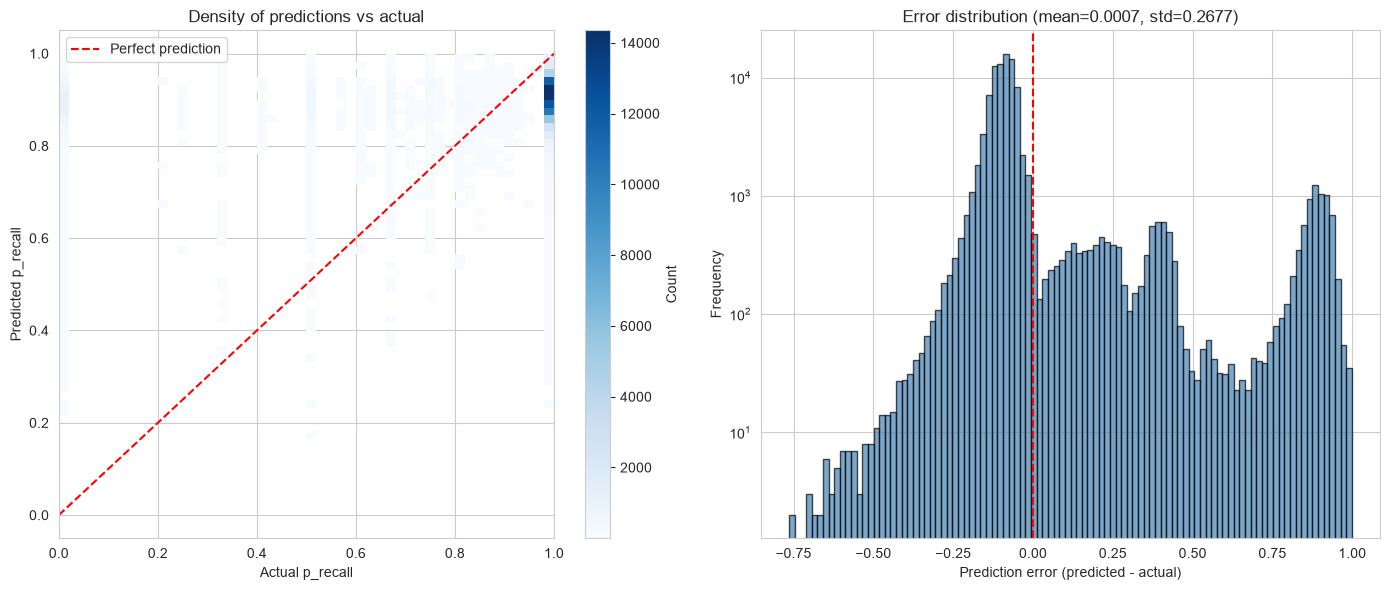

In [27]:
# Predictions vs actual (tuned Random Forest)
# Using a 2D histogram (heatmap) to show density, since most points overlap at (1.0, 1.0)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: density heatmap (shows where the actual mass of data is)
h = axes[0].hist2d(y_test, y_pred_tuned, bins=50, cmap='Blues', cmin=1)
axes[0].plot([0, 1], [0, 1], 'r--', label='Perfect prediction')
axes[0].set_xlabel('Actual p_recall')
axes[0].set_ylabel('Predicted p_recall')
axes[0].set_title('Density of predictions vs actual')
axes[0].legend()
plt.colorbar(h[3], ax=axes[0], label='Count')

# Right: error distribution (how far off are the predictions?)
errors = y_pred_tuned - y_test.values
axes[1].hist(errors, bins=100, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Prediction error (predicted - actual)')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Error distribution (mean={errors.mean():.4f}, std={errors.std():.4f})')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

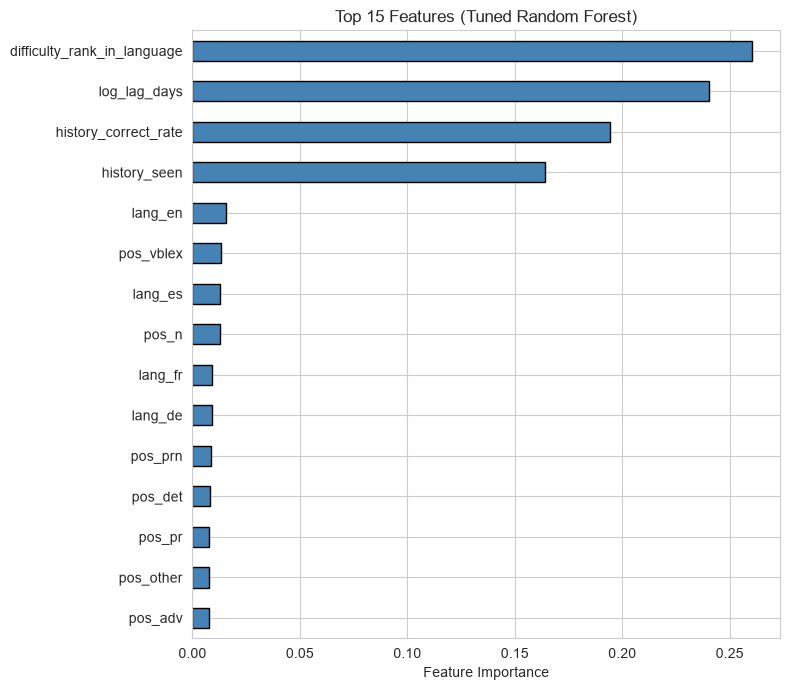

In [28]:
# Feature importance (tuned Random Forest)
importances = rf_search.best_estimator_.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))
feat_imp.tail(15).plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_xlabel('Feature Importance')
ax.set_title('Top 15 Features (Tuned Random Forest)')
plt.tight_layout()
plt.show()

## 8. Do NLP Features Help?

Our models achieve R² ~ 0.03 with context features alone. Can NLP features (word length, vowel ratio, part of speech, language pairs) improve this? We add them and retrain all three models on the same split to compare directly.

In [29]:
vowels = set('aeiouáéíóúàèìòùäëïöüâêîôû')
df['word_length'] = df['surface_form'].str.len()
df['lemma_length'] = df['lemma'].str.len()
df['vowel_count'] = df['surface_form'].apply(lambda w: sum(1 for c in w.lower() if c in vowels))
df['consonant_count'] = df['word_length'] - df['vowel_count']
df['vowel_ratio'] = df['vowel_count'] / df['word_length']

df['language_pair'] = df['ui_language'] + '_' + df['learning_language']
pair_dummies = pd.get_dummies(df['language_pair'], prefix='pair')
df_nlp = pd.concat([df, pair_dummies], axis=1)

nlp_cols = ['word_length', 'lemma_length', 'vowel_count', 'consonant_count', 'vowel_ratio'] + list(pair_dummies.columns)
X_nlp = pd.concat([X, df_nlp.loc[X.index, nlp_cols]], axis=1)

nlp_continuous = ['word_length', 'lemma_length', 'vowel_count', 'consonant_count', 'vowel_ratio']
X_nlp[nlp_continuous] = scaler.fit_transform(X_nlp[nlp_continuous])

X_train_nlp, X_test_nlp, _, _ = train_test_split(X_nlp, y, test_size=0.2, random_state=42)

lr_nlp = LinearRegression()
lr_nlp.fit(X_train_nlp, y_train)
r2_lr_nlp = r2_score(y_test, lr_nlp.predict(X_test_nlp))

rf_nlp = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_nlp.fit(X_train_nlp, y_train)
r2_rf_nlp = r2_score(y_test, rf_nlp.predict(X_test_nlp))

model_nlp = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(X_train_nlp.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])
model_nlp.compile(optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9), loss='mse', metrics=['mae'])
model_nlp.fit(X_train_nlp, y_train, epochs=20, batch_size=256, validation_split=0.1, verbose=0)
r2_nn_nlp = r2_score(y_test, model_nlp.predict(X_test_nlp, verbose=0).flatten())

print(f"{'Model':<25} {'R² (without NLP)':<20} {'R² (with NLP)':<20} {'Delta':<10}")
print("-" * 75)
print(f"{'Linear Regression':<25} {r2_lr:<20.4f} {r2_lr_nlp:<20.4f} {r2_lr_nlp - r2_lr:<+10.4f}")
print(f"{'Random Forest':<25} {r2_rf:<20.4f} {r2_rf_nlp:<20.4f} {r2_rf_nlp - r2_rf:<+10.4f}")
print(f"{'Neural Network':<25} {r2_nn:<20.4f} {r2_nn_nlp:<20.4f} {r2_nn_nlp - r2_nn:<+10.4f}")

/Users/I767808/Documents/data-science-i/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model                     R² (without NLP)     R² (with NLP)        Delta     
---------------------------------------------------------------------------
Linear Regression         0.0244               0.0244               +0.0000   
Random Forest             0.0264               0.0265               +0.0001   
Neural Network            0.0309               0.0315               +0.0005   


NLP features add negligible signal. The delta in R² is in the order of thousandths across all three models. Word surface properties (length, vowel composition) and language pair information do not help predict recall once time elapsed, exposure history, and word difficulty are already accounted for.

### Conclusions

**Results without data leakage (full dataset, no session variables):**

| Model | RMSE | R² |
|---|---|---|
| Linear Regression | 0.2679 | 0.024 |
| Random Forest | 0.2677 | 0.026 |
| Random Forest (tuned) | 0.2677 | 0.026 |
| Neural Network | 0.2671 | 0.030 |

All models explain only 2-3% of the variance in recall. Adding NLP features (word length, vowel ratio, language pairs) does not change this: the delta in R² is negligible.

**Why is R² so low?**

The target distribution is extreme: 84% of values are exactly 1.0. When you remove session variables, the only signal left is weak (time elapsed, practice history, difficulty). Two users with identical profiles can have p_recall = 1.0 or p_recall = 0.0 depending on factors not in the data (attention, sleep, mood). The model defaults to predicting values near the mean, which gives low R².

**Key takeaway**: Predicting exact recall probability from context alone is extremely hard. The features available in this dataset (without session-level outcomes) capture only a small fraction of what determines whether a learner will remember a word.